In [37]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [38]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [39]:
df.head(5)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


<Axes: >

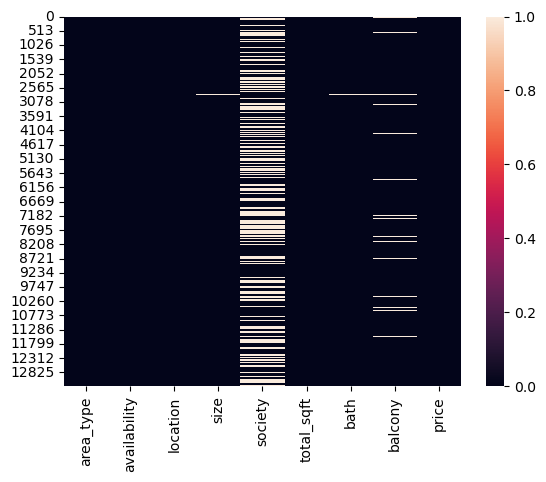

In [40]:
sns.heatmap(df.isnull())

# handle null values

In [42]:
df.isnull().sum() / df.shape[0] * 100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

In [43]:
dfNullColumns = df.isnull().sum().to_frame("Null Percentage")
dfNullColumns["Null Percentage"] = dfNullColumns["Null Percentage"] / df.shape[0] * 100
dfNullColumns

,Null Percentage
area_type,0.000000
availability,0.000000
location,0.007508
size,0.120120
society,41.306306
total_sqft,0.000000
bath,0.548048
balcony,4.572072
price,0.000000


In [44]:
columnsWithNullValues = dfNullColumns[dfNullColumns["Null Percentage"] > 0]
columnsWithNullValues

,Null Percentage
location,0.007508
size,0.120120
society,41.306306
bath,0.548048
balcony,4.572072


In [45]:
columnsToBeDeleted = dfNullColumns[dfNullColumns["Null Percentage"] > 20]
dropColumns = columnsToBeDeleted.index
dropColumns

Index(['society'], dtype='object')

In [46]:
dfAfterEDA = df #copy of the og data

In [47]:
dfAfterEDA = dfAfterEDA.drop(columns = dropColumns)
dfAfterEDA.head(5)

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


<Axes: >

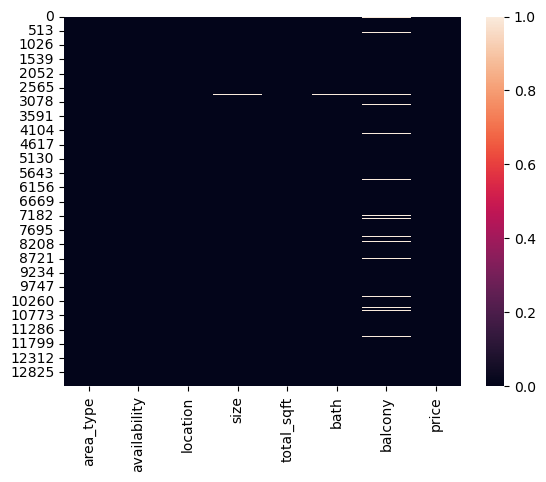

In [48]:
sns.heatmap(dfAfterEDA.isnull())

In [49]:
dfAfterEDA.select_dtypes(include = ["int64", "float64"]).head(5)

,bath,balcony,price
0,2.0,1.0,39.07
1,5.0,3.0,120.00
2,2.0,3.0,62.00
3,3.0,1.0,95.00
4,2.0,1.0,51.00


In [50]:
dfAfterEDA["bath"] = dfAfterEDA["bath"].fillna(dfAfterEDA["bath"].mean())
dfAfterEDA["bath"].isnull().sum()

0

In [51]:
dfAfterEDA["balcony"] = dfAfterEDA["balcony"].fillna(dfAfterEDA["balcony"].mean())
dfAfterEDA["balcony"].isnull().sum()

0

In [52]:
dfAfterEDA.select_dtypes(include = ["object"]).head(5)

,area_type,availability,location,size,total_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200


<Axes: >

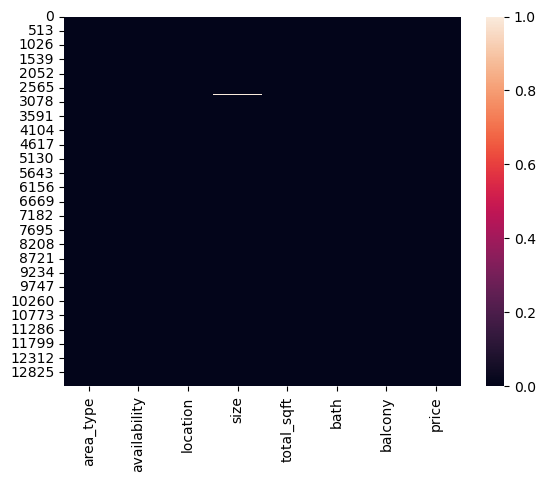

In [53]:
sns.heatmap(dfAfterEDA.isnull())

In [54]:
dfAfterEDA = dfAfterEDA.dropna()

<Axes: >

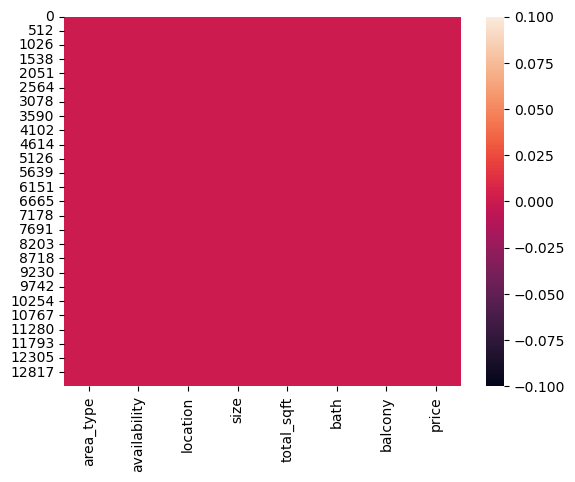

In [55]:
sns.heatmap(dfAfterEDA.isnull())

# encoding

In [57]:
dfAfterEDA["area_type"].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [58]:
OneHot = OneHotEncoder(drop = None, sparse_output = False)

In [59]:
area_typeOneHotEncoded = OneHot.fit_transform(dfAfterEDA[["area_type"]])
area_typeOneHotEncodedDf = pd.DataFrame(area_typeOneHotEncoded, columns = OneHot.get_feature_names_out(["area_type"]), index = dfAfterEDA.index)
dfAfterEDA = pd.concat([dfAfterEDA, area_typeOneHotEncodedDf], axis = 1)
dfAfterEDA = dfAfterEDA.drop(columns = ["area_type"])
dfAfterEDA.head(5)

,availability,location,size,total_sqft,bath,balcony,price,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,0.0,0.0,0.0,1.0
1,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,0.0,0.0,1.0,0.0
2,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1.0,0.0,0.0,0.0
3,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,0.0,0.0,0.0,1.0
4,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,0.0,0.0,0.0,1.0


In [60]:
dfAfterEDA["availability"] = dfAfterEDA["availability"].isin(["Ready To Move"]).astype(int)
dfAfterEDA.head(5)

,availability,location,size,total_sqft,bath,balcony,price,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,0.0,0.0,0.0,1.0
1,1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,0.0,0.0,1.0,0.0
2,1,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1.0,0.0,0.0,0.0
3,1,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,0.0,0.0,0.0,1.0
4,1,Kothanur,2 BHK,1200,2.0,1.0,51.00,0.0,0.0,0.0,1.0


In [61]:
dfAfterEDA["size"].value_counts()

size
2 BHK         5199
3 BHK         4309
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [62]:
dfAfterEDA["size"] = dfAfterEDA["size"].str.split(" ").str[0].astype(int)
dfAfterEDA.head(5)

,availability,location,size,total_sqft,bath,balcony,price,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0,Electronic City Phase II,2,1056,2.0,1.0,39.07,0.0,0.0,0.0,1.0
1,1,Chikka Tirupathi,4,2600,5.0,3.0,120.00,0.0,0.0,1.0,0.0
2,1,Uttarahalli,3,1440,2.0,3.0,62.00,1.0,0.0,0.0,0.0
3,1,Lingadheeranahalli,3,1521,3.0,1.0,95.00,0.0,0.0,0.0,1.0
4,1,Kothanur,2,1200,2.0,1.0,51.00,0.0,0.0,0.0,1.0


In [63]:
loc = dfAfterEDA["location"].value_counts().head(10).keys()

In [64]:
dfAfterEDA["location"].isin(loc).head(5)

0    False
1    False
2     True
3    False
4    False
Name: location, dtype: bool

In [65]:
loc

Index(['Whitefield', 'Sarjapur  Road', 'Electronic City', 'Kanakpura Road',
       'Thanisandra', 'Yelahanka', 'Uttarahalli', 'Hebbal', 'Marathahalli',
       'Raja Rajeshwari Nagar'],
      dtype='object', name='location')

In [66]:
dfAfterEDA["location"].value_counts() < 171

location
Whitefield                                            False
Sarjapur  Road                                        False
Electronic City                                       False
Kanakpura Road                                        False
Thanisandra                                           False
Yelahanka                                             False
Uttarahalli                                           False
Hebbal                                                False
Marathahalli                                          False
Raja Rajeshwari Nagar                                 False
Hennur Road                                            True
Bannerghatta Road                                      True
7th Phase JP Nagar                                     True
Haralur Road                                           True
Electronic City Phase II                               True
Rajaji Nagar                                           True
Chandapura                     

In [67]:
temp1 = dfAfterEDA["location"].map(dfAfterEDA["location"].value_counts() < 171)

In [68]:
dfAfterEDA.loc[temp1, "location"] = "Other"

In [69]:
dfAfterEDA.head(10)

,availability,location,size,total_sqft,bath,balcony,price,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0,Other,2,1056,2.0,1.000000,39.07,0.0,0.0,0.0,1.0
1,1,Other,4,2600,5.0,3.000000,120.00,0.0,0.0,1.0,0.0
2,1,Uttarahalli,3,1440,2.0,3.000000,62.00,1.0,0.0,0.0,0.0
3,1,Other,3,1521,3.0,1.000000,95.00,0.0,0.0,0.0,1.0
4,1,Other,2,1200,2.0,1.000000,51.00,0.0,0.0,0.0,1.0
5,1,Whitefield,2,1170,2.0,1.000000,38.00,0.0,0.0,0.0,1.0
6,0,Other,4,2732,4.0,1.584376,204.00,0.0,0.0,0.0,1.0
7,1,Other,4,3300,4.0,1.584376,600.00,0.0,0.0,0.0,1.0
8,1,Marathahalli,3,1310,3.0,1.000000,63.25,0.0,0.0,0.0,1.0
9,1,Other,6,1020,6.0,1.584376,370.00,0.0,0.0,1.0,0.0


In [70]:
temp2 = dfAfterEDA["location"].value_counts()

In [71]:
dfAfterEDA["location"].map(temp2)

0        10637
1        10637
2          186
3        10637
4        10637
5          539
6        10637
7        10637
8          175
9        10637
10         539
11         539
12       10637
13       10637
14       10637
15       10637
16       10637
17         171
18       10637
19       10637
20       10637
21       10637
22         234
23       10637
24       10637
25       10637
26         302
27         539
28       10637
29         302
30         212
31       10637
32         177
33         171
34       10637
35         273
36       10637
37       10637
38       10637
39         186
40       10637
41         397
42       10637
43         212
44         273
45       10637
46       10637
47         539
48       10637
49       10637
50       10637
51       10637
52         539
53       10637
54         212
55       10637
56       10637
57       10637
58       10637
59       10637
60       10637
61       10637
62         539
63       10637
64       10637
65       10637
66       1

In [72]:
targetEncoderForLocation = dfAfterEDA.groupby("location")["price"].mean()
targetEncoderForLocation

location
Electronic City           54.972384
Hebbal                   160.814915
Kanakpura Road            70.533791
Marathahalli             102.213714
Other                    116.466940
Raja Rajeshwari Nagar     64.714035
Sarjapur  Road           119.381549
Thanisandra               82.725598
Uttarahalli               61.252527
Whitefield               128.200232
Yelahanka                 86.444646
Name: price, dtype: float64

In [73]:
dfAfterEDA["location"] = dfAfterEDA["location"].map(targetEncoderForLocation)

In [74]:
dfAfterEDA.head(10)

,availability,location,size,total_sqft,bath,balcony,price,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0,116.466940,2,1056,2.0,1.000000,39.07,0.0,0.0,0.0,1.0
1,1,116.466940,4,2600,5.0,3.000000,120.00,0.0,0.0,1.0,0.0
2,1,61.252527,3,1440,2.0,3.000000,62.00,1.0,0.0,0.0,0.0
3,1,116.466940,3,1521,3.0,1.000000,95.00,0.0,0.0,0.0,1.0
4,1,116.466940,2,1200,2.0,1.000000,51.00,0.0,0.0,0.0,1.0
5,1,128.200232,2,1170,2.0,1.000000,38.00,0.0,0.0,0.0,1.0
6,0,116.466940,4,2732,4.0,1.584376,204.00,0.0,0.0,0.0,1.0
7,1,116.466940,4,3300,4.0,1.584376,600.00,0.0,0.0,0.0,1.0
8,1,102.213714,3,1310,3.0,1.000000,63.25,0.0,0.0,0.0,1.0
9,1,116.466940,6,1020,6.0,1.584376,370.00,0.0,0.0,1.0,0.0


In [75]:
dfAfterEDA["total_sqft"].str.split(" ").str[0].astype(float)

ValueError: could not convert string to float: '34.46Sq.'